<a href="https://colab.research.google.com/github/diazveraserrano-boop/Procesamiento-de-Imagen/blob/main/Imagen1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
En esta actividad llevaremos a cabo la detección de patógenos y células teñidas en un cultivo celular. Para ello, probaremos diferentes métodos de segmentación.

In [1]:
!pip install onedrivedownloader
from onedrivedownloader import download
import skimage.io as io
from skimage.color import rgb2hsv, rgb2gray
from skimage.filters import gaussian, threshold_otsu
from skimage.morphology import disk, opening, closing, remove_small_objects
from skimage.measure import label, regionprops
import matplotlib.pyplot as plt
import numpy as np

In [2]:
path_file_1 = 'https://universidadfv-my.sharepoint.com/:i:/g/personal/alberto_desantos_ufv_es/ESWcU3soWRFFhKUIBOoH2uUBZq6M5T5jrYA-cYK1YprwJg?e=LBz2yk'
download(url = path_file_1, filename = 'Imagen 1.jpg', unzip=False, force_download=True, clean=False)

  # Ejemplo HMEC phase contrast (usa solo izquierda si composite)

100%|██████████| 46.8k/46.8k [00:00<00:00, 640kiB/s]


'Imagen 1.jpg'

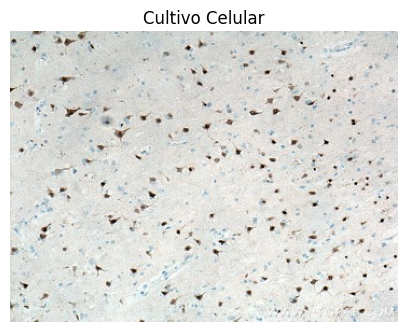

In [3]:
img1 = io.imread('/content/Imagen 1.jpg')

plt.figure(figsize=(5, 5))
plt.imshow(img1)
plt.title('Cultivo Celular')
plt.axis('off')
plt.show()

Vamos a probar cómo sería la imagen en otra gama de colores, ya que en RGB es más complicado diferenciar las células teñidas en azul del fondo blanco.

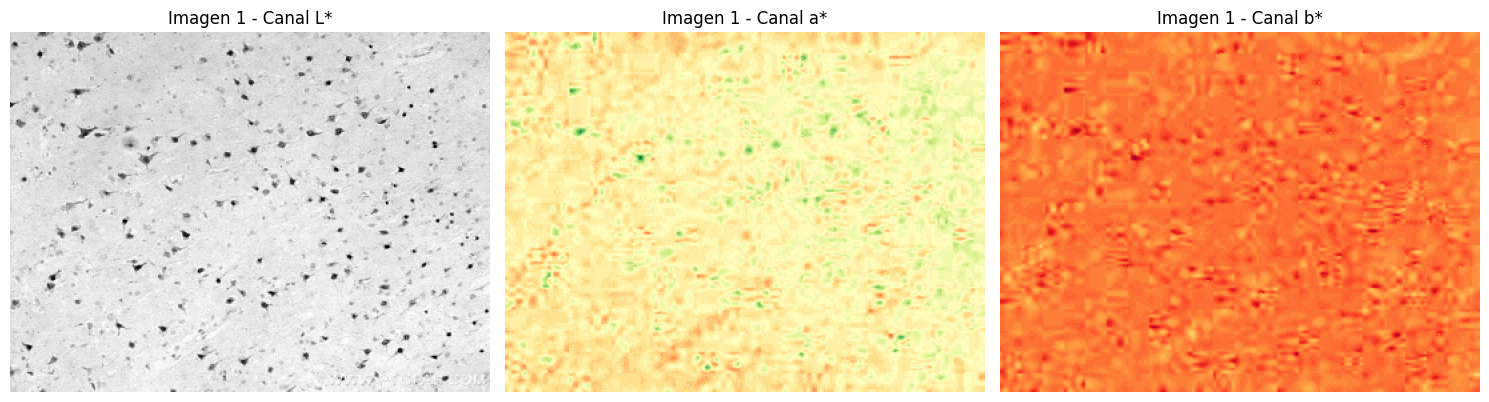

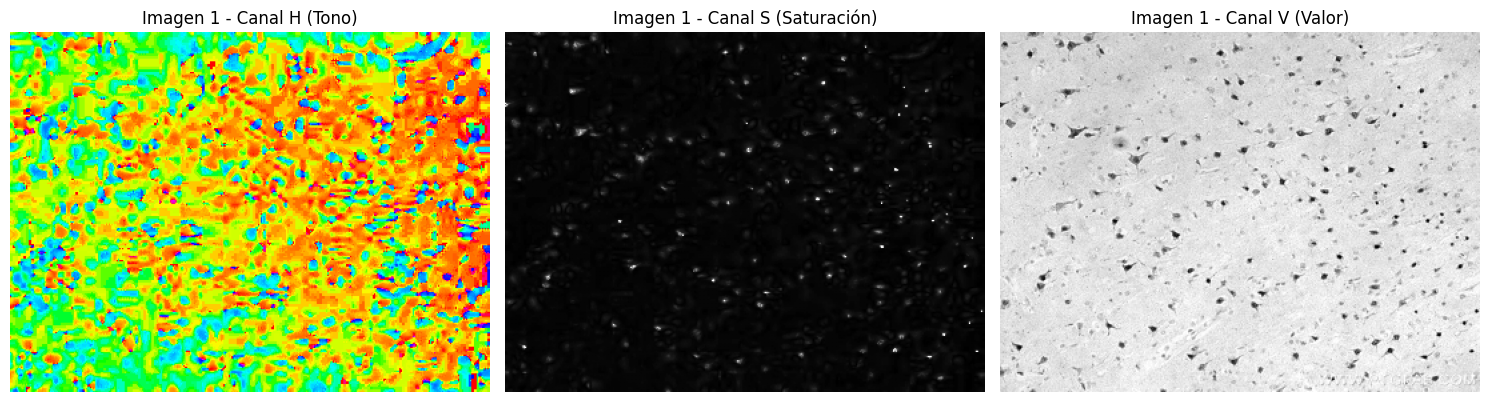

In [4]:
from skimage.color import rgb2lab, rgb2hsv
import matplotlib.pyplot as plt
import numpy as np

# Convertir Imagen 1 a espacio de color L*a*b*
img1_lab = rgb2lab(img1)

# Visualizar los canales L*, a* y b* por separado
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Canal L* (Luminosidad)
axes[0].imshow(img1_lab[:, :, 0], cmap='gray')
axes[0].set_title('Imagen 1 - Canal L*')
axes[0].axis('off')

# Canal a* (Verde a Rojo)
a_channel = img1_lab[:, :, 1]
max_abs_a = np.max(np.abs(a_channel))
axes[1].imshow(a_channel, cmap='RdYlGn', vmin=-max_abs_a, vmax=max_abs_a)
axes[1].set_title('Imagen 1 - Canal a*')
axes[1].axis('off')

# Canal b* (Azul a Amarillo)
b_channel = img1_lab[:, :, 2]
max_abs_b = np.max(np.abs(b_channel))
axes[2].imshow(b_channel, cmap='YlOrRd', vmin=-max_abs_b, vmax=max_abs_b)
axes[2].set_title('Imagen 1 - Canal b*')
axes[2].axis('off')

plt.tight_layout()
plt.show()


# Convertir Imagen 1 a espacio de color HSV
img1_hsv = rgb2hsv(img1)

# Visualizar los canales H, S y V por separado
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Canal H (Tono)
axes[0].imshow(img1_hsv[:, :, 0], cmap='hsv') # Usamos cmap='hsv' para visualizar el tono
axes[0].set_title('Imagen 1 - Canal H (Tono)')
axes[0].axis('off')

# Canal S (Saturación)
axes[1].imshow(img1_hsv[:, :, 1], cmap='gray')
axes[1].set_title('Imagen 1 - Canal S (Saturación)')
axes[1].axis('off')

# Canal V (Valor/Brillo)
axes[2].imshow(img1_hsv[:, :, 2], cmap='gray')
axes[2].set_title('Imagen 1 - Canal V (Valor)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Tras analizar las distintas capas de los espacios de color LAB y HSV, se observa que la capa H (Hue) es la que ofrece una mejor separación de tonalidades, mientras que las variaciones de brillo resultan menos relevantes para distinguir las regiones de interés.

A diferencia del modelo RGB, que combina información de color e intensidad luminosa, la capa H se centra exclusivamente en el matiz, lo que facilita una segmentación más precisa basada en el color.
Por este motivo, se aplicará una segmentación por clústeres (k = 5) en el espacio de color HSV.

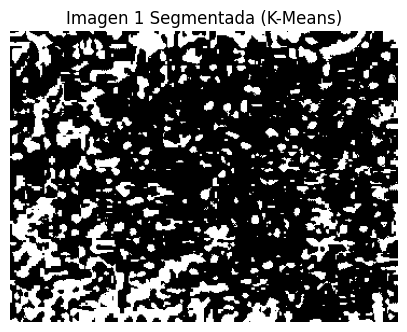

In [5]:
from sklearn.cluster import KMeans
# Segmentación con K-Means para Imagen 1 (a color)
# Redimensionar la imagen a un arreglo de características (pixeles como filas, RGB como columnas)

img1_2d = img1_hsv.reshape(-1, 3)
kmeans = KMeans(n_clusters=5, random_state=42).fit(img1_2d)
segmented_img1 = kmeans.labels_.reshape(img1_hsv.shape[:2])

# Convertir la segmentación a binaria (asumiendo que el clúster 0 representa las células)
binary_segmented1 = segmented_img1 == 0 # Ajusta el clúster según el resultado visual

# Visualización de resultados
plt.figure(figsize=(5, 5))
plt.imshow(binary_segmented1, cmap='grey')
plt.title('Imagen 1 Segmentada (K-Means)')
plt.axis('off')
plt.show()

Convertimos el color blanco de la máscara en rojo para facilitar la visualización de la segmentación al superponerla sobre la imagen original.

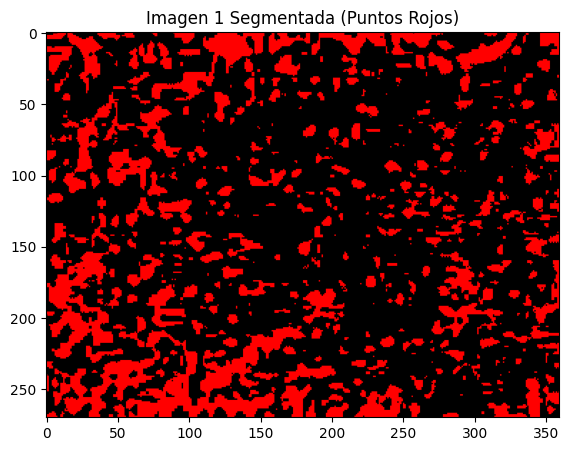

In [6]:
# Cambiar color de los puntos negros a rojo en la imagen segmentada 1
segmented_img1_color = np.stack((binary_segmented1, binary_segmented1, binary_segmented1), axis=-1).astype(float) # Convert to float
segmented_img1_color[binary_segmented1] = [1, 0, 0] # Cambiar los píxeles negros (False en la binaria) a rojo [1, 0, 0]

# Visualizar la imagen segmentada 1 con puntos rojos
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.imshow(segmented_img1_color)
ax.set_title('Imagen 1 Segmentada (Puntos Rojos)')
plt.show()

Usamos un canal alfa para hacer transparentes las partes no segmentadas de la imagen segmentada. Concatenamos el canal alfa a la imagen RGB segmentada para crear una imagen RGBA.

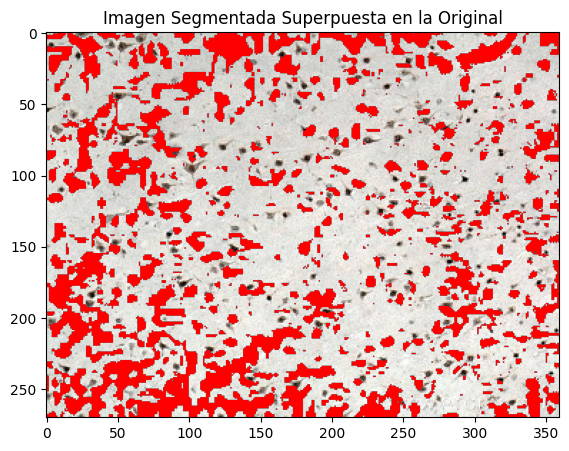

In [7]:
# Superponer la imagen segmentada (con puntos rojos) sobre la imagen original a color

# Crear una imagen RGBA a partir de la imagen segmentada a color
# Donde los píxeles rojos (los segmentados) tendrán opacidad total y los demás serán transparentes
segmented_img1_lab = np.concatenate([segmented_img1_color, np.zeros_like(binary_segmented1)[:, :, np.newaxis]], axis=-1)
segmented_img1_lab[binary_segmented1] = [1, 0, 0, 1] # Píxeles rojos (segmentados) con opacidad total

# Visualizar la superposición
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.imshow(img1) # Mostrar la imagen original
ax.imshow(segmented_img1_lab) # Superponer la imagen segmentada con transparencia
ax.set_title('Imagen Segmentada Superpuesta en la Original')
plt.show()

Ahora que hemos comprobado que la segmentación no es del todo correcta, vamos a llevar a cabo una umbralización adaptativa. El principal problema que veíamos antes era la iluminación no uniforme. En la zona de arriba de la imagen el color de los pixeles del fondo varía respecto a la zona de abajo de la imagen.

Con una umbralización adaptativa, dividimos la imagen en secciones y calculamos el umbral de cada una basado en el histograma de cada una de esas secciones. Esto permite ajustar el umbral de forma independiente en áreas con distinta iluminación, obteniendo así una segmentación más equilibrada y precisa.

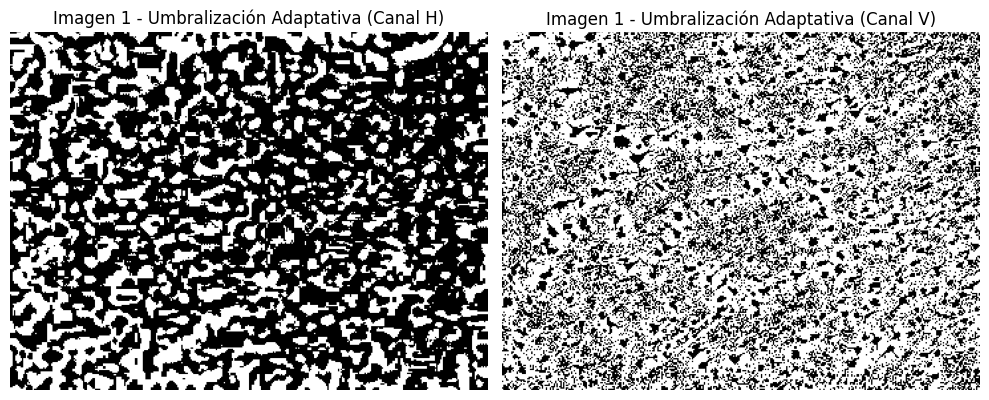

In [8]:
from skimage.color import rgb2hsv
from skimage.filters import threshold_local
import matplotlib.pyplot as plt

# Convertir Imagen 1 al espacio de color HSV
img1_hsv = rgb2hsv(img1)

# Extraer los canales H (matiz) y V (valor/brillo) de la imagen HSV
img1_h_channel = img1_hsv[:, :, 0]  # Canal H: representa el tipo de color (0-1, equivalente a 0-360°)
img1_v_channel = img1_hsv[:, :, 2]  # Canal V: representa el brillo (0-1)

# Nota: Los canales H y V en skimage.rgb2hsv ya están normalizados en [0, 1],
# por lo que no es necesaria una normalización adicional para threshold_local.

# Aplicar umbralización adaptativa (threshold_local) a los canales H y V
# block_size: tamaño de la vecindad local para calcular el umbral (debe ser impar)
# offset: valor constante restado del umbral medio local para ajustar la sensibilidad
block_size = 35  # Ajustar según el tamaño de los objetos y la variación de iluminación
adaptive_thresh_h = threshold_local(img1_h_channel, block_size, offset=0)
binary_h_adaptive = img1_h_channel > adaptive_thresh_h
adaptive_thresh_v = threshold_local(img1_v_channel, block_size, offset=0)
binary_v_adaptive = img1_v_channel > adaptive_thresh_v

# Visualizar las imágenes binarias resultantes
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(binary_h_adaptive, cmap='gray')
ax[0].set_title('Imagen 1 - Umbralización Adaptativa (Canal H)')
ax[0].axis('off')

ax[1].imshow(binary_v_adaptive, cmap='gray')
ax[1].set_title('Imagen 1 - Umbralización Adaptativa (Canal V)')
ax[1].axis('off')

plt.tight_layout()
plt.show()

Tras realizar la umbralización adaptativa de las capas H y V (porque la S no nos aporta demasiado para resolver el problema de reconocimiento de células con respecto del fondo), no damos cuenta de que la umbralización del canal V parece bastante buena para reconocimiento de patógenos. Sugiere una buena detección de los patógenos pero confunde mucho el fondo con las células. Para comprobarlo, volvemos a cambiar la tonalidad del negro a rojo, manteniendo todo igual.

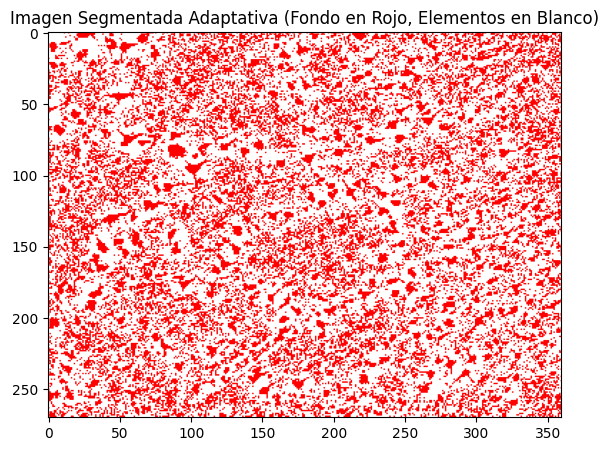

In [9]:
# Cambiar color de los elementos no segmentados (False en la binaria) a rojo, mantener los segmentados (True) en blanco
# Creamos una imagen RGB con el mismo tamaño que la binaria, inicializada a blanco.
segmented_adaptive_color = np.ones(img1.shape[:2] + (3,), dtype=float)

# Asignamos color rojo a los píxeles donde binary_adaptive es False (usamos el operador ~ para invertir la máscara)
segmented_adaptive_color[~binary_v_adaptive] = [1, 0, 0] # Rojo [1, 0, 0]

# Visualizar la imagen con los elementos no segmentados en rojo y los segmentados en blanco
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.imshow(segmented_adaptive_color)
ax.set_title('Imagen Segmentada Adaptativa (Fondo en Rojo, Elementos en Blanco)')
plt.show()

Superponemos esta última imagen modificada de color con la original, para determinar si la detección de patógenos es adecuada o no. De nuevo, creamos una imagen RGBA donde solo los píxeles correspondientes al fondo segmentado tienen color (rojo) y opacidad parcial. Esto permite superponer solo el fondo segmentado sobre la imagen original, dejando los elementos segmentados originales visibles.

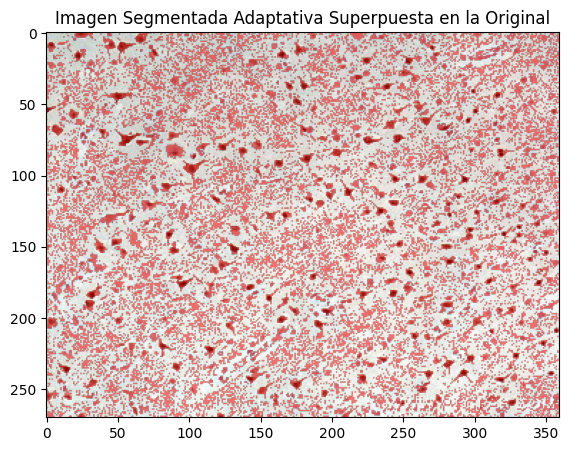

In [10]:
# Superponer la imagen segmentada adaptativa (blanco y rojo) sobre la imagen original a color

# Creamos una imagen RGBA a partir de la imagen segmentada a color (blanco y rojo)
# Inicializamos con transparencia total (canal alfa = 0)
segmented_adaptive_rgba = np.zeros((img1.shape[0], img1.shape[1], 4), dtype=float) # Corrected shape

# Asignamos color rojo y opacidad parcial a los píxeles que eran rojos (el fondo segmentado)
# Usamos la misma máscara que antes (~binary_adaptive) para identificar estos píxeles
segmented_adaptive_rgba[~binary_v_adaptive] = [1, 0, 0, 0.5] # Rojo [1, 0, 0] con 50% de opacidad (ajusta 0.5 si es necesario)

# Visualizar la superposición
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.imshow(img1) # Mostrar la imagen original
ax.imshow(segmented_adaptive_rgba) # Superponer la imagen segmentada con transparencia
ax.set_title('Imagen Segmentada Adaptativa Superpuesta en la Original')
plt.show()

Como vemos, la identificación de elementos más importantes (patógenos) ha mejorado de forma significativa realizando una umbralización adaptativa, la cual se amolda mejor a cambios en iluminación de la imagen. Se reconocen todos los patógenos de la imagen.

Concluimos que es una muy buena opción la segmentación mediante umbralización adaptativa de la capa V (similar a la capa L de LAB) para detección de patógenos: por ejemplo en casos donde las células no sean tan importantes de reconocer (para detectar enfermedades).

No obstante, queremos ir más allá. Queremos ser capaces de reconocer las células en la imagen, por lo que probaremos de otra forma: mediante operaciones de morfología matemática.

Lo que queremos ver con estas operaciones es si los elementos azules claro están "atrapados" debajo del fondo. Con estas operaciones buscamos eliminar el fondo y ver si se reconocen bien las células o si, por el contrario, se hace una eliminación aleatoria (porque se sigue reconociendo igual el fondo que las células).

Realizaremos una erosión seguida de una dilatación con un elemento estructural en forma de diamante. Probamos con el círculo, pero al no tener bordes, pensamos que sería mehor el diamante para detectar estos salientes de algunas células.

Estas operaciones se aplicaron sobre la imagen umbralizada adaptativamente, pero invertida, de modo que la secuencia de erosión y posterior dilatación (una apertura) actuara de manera más eficaz sobre las regiones de interés.

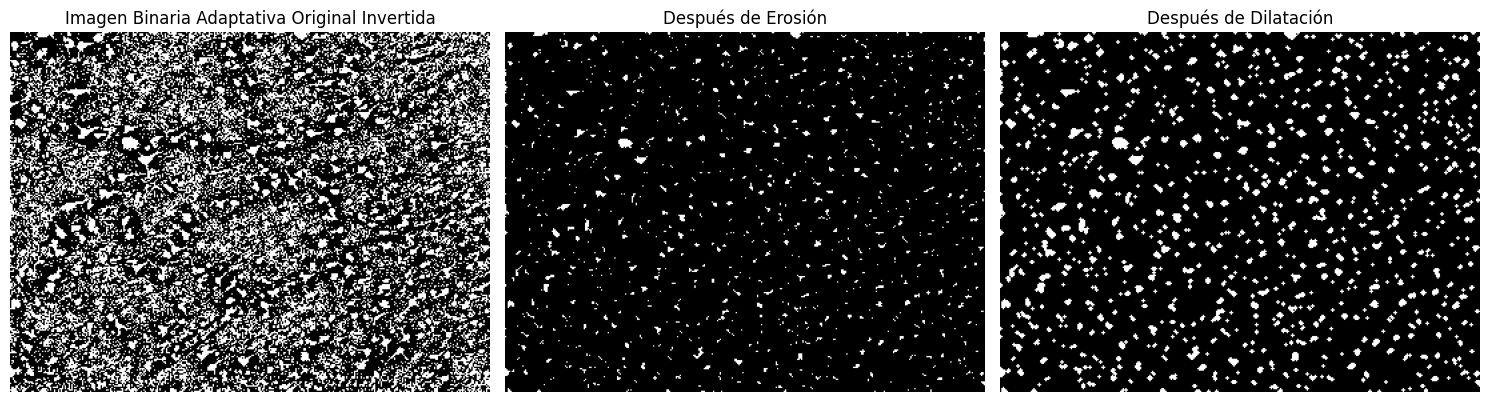

In [11]:
from skimage.morphology import erosion, dilation, disk, diamond

# Definir elementos estructurantes (ajusta el tamaño según sea necesario)
selem_erosion = diamond(1.8)
selem_dilation = diamond(1)

# Aplicar erosión a la imagen original
binary_eroded = erosion(~binary_v_adaptive, selem_erosion)

binary_dilated = dilation(binary_eroded, selem_dilation)

# Visualizar los resultados de las operaciones morfológicas
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(binary_v_adaptive, cmap='gray')
axes[0].set_title('Imagen Binaria Adaptativa Original')
axes[0].axis('off')

axes[0].imshow(~binary_v_adaptive, cmap='gray')
axes[0].set_title('Imagen Binaria Adaptativa Original Invertida')
axes[0].axis('off')

axes[1].imshow(binary_eroded, cmap='gray')
axes[1].set_title('Después de Erosión')
axes[1].axis('off')

axes[2].imshow(binary_dilated, cmap='gray') # Display the result of dilation then erosion
axes[2].set_title('Después de Dilatación')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Como observamos, se ha eliminado gran parte del fondo, lo que *a priori* puede sugerir que las células están bien reconocidas. Para ver si es correcto, vamos a volver a invertir la imagen, cambiarla de color (crear de nuevo la imagen en RGBA) y superponerla con la original.

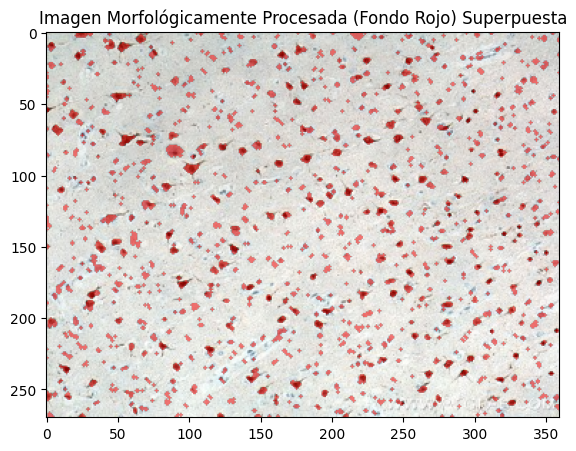

In [12]:
# Superponer la imagen binaria morfológicamente procesada (dilatada e invertida) sobre la imagen original a color

# Invertir la imagen binaria dilatada: True se vuelve False y False se vuelve True.
# Esto es para que los elementos que eran 'negros' (False) ahora sean 'blancos' (True) y viceversa.
binary_dilated_inverted = binary_dilated

# Creamos una imagen RGBA a partir de la máscara binaria invertida
# Los píxeles donde binary_dilated_inverted es True (que eran False en binary_dilated, es decir, el fondo) serán rojos y opacos.
# Los píxeles donde binary_dilated_inverted es False (que eran True en binary_dilated, es decir, los elementos) serán transparentes.
# Inicializamos con transparencia total (canal alfa = 0)
segmented_morph_inverted_rgba = np.zeros((img1.shape[0], img1.shape[1], 4), dtype=float) # Corrected shape

# Asignamos color rojo y opacidad parcial a los píxeles donde binary_dilated_inverted es True (el fondo original)
segmented_morph_inverted_rgba[binary_dilated_inverted] = [1, 0, 0, 0.5] # Rojo [1, 0, 0] con 50% de opacidad

# Visualizar la superposición
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.imshow(img1) # Mostrar la imagen original
ax.imshow(segmented_morph_inverted_rgba) # Superponer la imagen segmentada (fondo rojo) con transparencia
ax.set_title('Imagen Morfológicamente Procesada (Fondo Rojo) Superpuesta')
plt.show()

A primera vista, el resultado parece correcto. Sin embargo, al observarlo con más detenimiento, notamos que las operaciones morfológicas se aplican de manera “aleatoria” sobre el fondo. Esto indica que, desde el inicio, el modelo está reconociendo el fondo y las células de la misma forma, por lo que las operaciones posteriores no marcan ninguna diferencia. El resultado es evidente: células que no se identifican correctamente y zonas completamente blancas donde se “detectan” falsamente células.

En un principio no fuimos capaces de detectar esto, y realizamos la misma dinámica pero sin invertir la imagen umbralizada adaptativamente y ejecutando primero la dilatación y después la erosión. El resultado final fue similar. Dilatación y erosión (clausura) de fondo, sin identificar células en ingún momento.

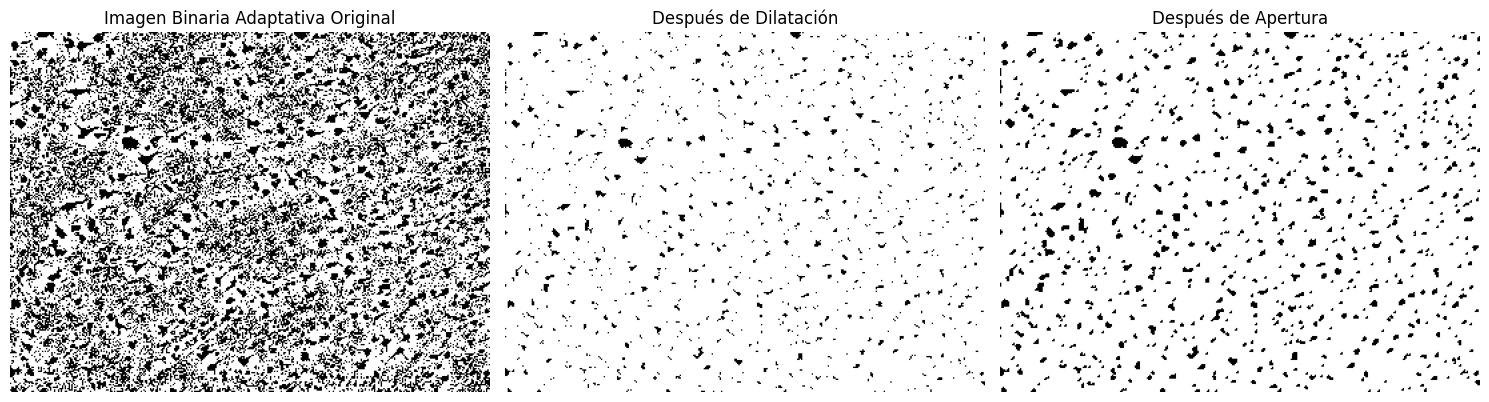

In [13]:
from skimage.morphology import erosion, dilation, disk, diamond

# Definir elementos estructurantes (ajusta el tamaño según sea necesario)
selem_erosion = diamond(1.25) # Un disco de radio 2 como ejemplo para erosión
selem_dilation = diamond(1.7) # Un disco de radio 1 como ejemplo para dilatación

# Aplicar dilatación a la imagen binaria adaptativa
binary_dilated = dilation(binary_v_adaptive, selem_dilation)

# Aplicar erosión a la imagen dilatada
binary_opened = erosion(binary_dilated, selem_erosion) # Renamed for clarity (Opening)

# Visualizar los resultados de las operaciones morfológicas
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(binary_v_adaptive, cmap='gray')
axes[0].set_title('Imagen Binaria Adaptativa Original')
axes[0].axis('off')

axes[1].imshow(binary_dilated, cmap='gray')
axes[1].set_title('Después de Dilatación')
axes[1].axis('off')

axes[2].imshow(binary_opened, cmap='gray') # Display the result of dilation then erosion
axes[2].set_title('Después de Apertura')
axes[2].axis('off')

plt.tight_layout()
plt.show()

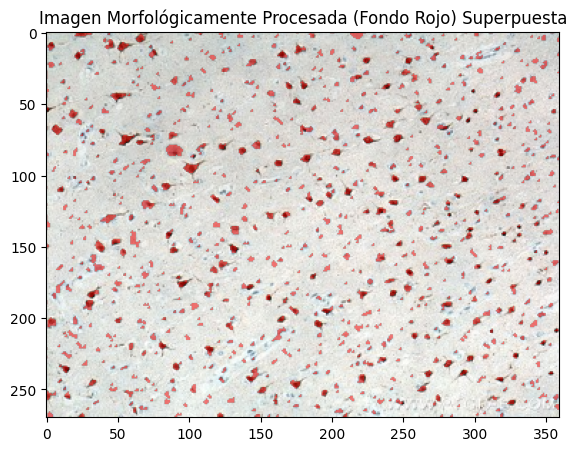

In [14]:
# Superponer la imagen binaria morfológicamente procesada (dilatada e invertida) sobre la imagen original a color

# Invertir la imagen binaria dilatada: True se vuelve False y False se vuelve True.
# Esto es para que los elementos que eran 'negros' (False) ahora sean 'blancos' (True) y viceversa.
binary_opened_inverted = binary_opened

# Creamos una imagen RGBA a partir de la máscara binaria invertida
# Los píxeles donde binary_dilated_inverted es True (que eran False en binary_dilated, es decir, el fondo) serán rojos y opacos.
# Los píxeles donde binary_dilated_inverted es False (que eran True en binary_dilated, es decir, los elementos) serán transparentes.
# Inicializamos con transparencia total (canal alfa = 0)
segmented_morph_inverted_rgba = np.zeros((img1.shape[0], img1.shape[1], 4), dtype=float) # Corrected shape

# Asignamos color rojo y opacidad parcial a los píxeles donde binary_dilated_inverted es True (el fondo original)
segmented_morph_inverted_rgba[~binary_opened_inverted] = [1, 0, 0, 0.5] # Rojo [1, 0, 0] con 50% de opacidad

# Visualizar la superposición
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.imshow(img1) # Mostrar la imagen original
ax.imshow(segmented_morph_inverted_rgba) # Superponer la imagen segmentada (fondo rojo) con transparencia
ax.set_title('Imagen Morfológicamente Procesada (Fondo Rojo) Superpuesta')
plt.show()

Nos damos cuenta, una vez más, de que el problema sigue estando en el reconocimiento de la imagen. Por ello, decidimos probar una nueva estrategia: intensificar la tonalidad azul en la capa H de la imagen. De este modo, esperamos que las células se identifiquen con mayor precisión, al resaltar mejor los tonos característicos de su coloración.

Se nos ocurrió aumentar la tonalidad de las células, para así distinguirlas mejor y poder hacer la segmentación por clústers de manera más óptima. Las células teñidas de azul claro se trataron con una máscara basada en el tono (H) y la saturación (S) en el espacio de color HSV. Definimos un rango específico de matiz y baja saturación para capturar únicamente los píxeles de las células (sin incluir el fondo), generamos una máscara binaria que marca esas regiones, y luego intensificamos selectivamente el color azul solo en dichas zonas: aumentamos la saturación, el brillo y ajustamos ligeramente el tono hacia un azul más definido.

Pixeles azules detectados: 7188 / 97200 (7.40%)


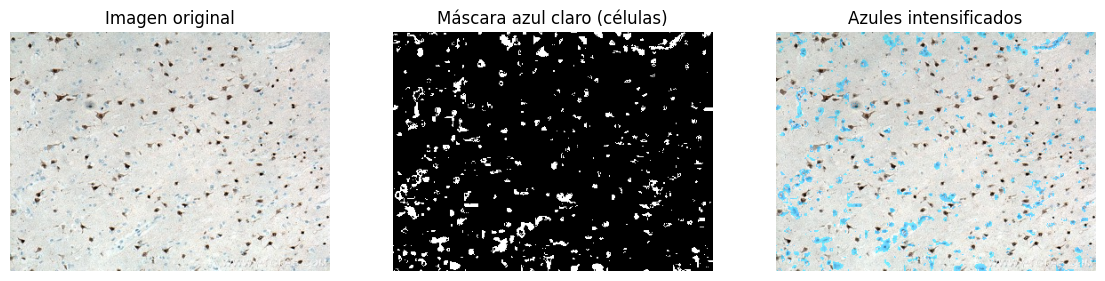

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2hsv, hsv2rgb
import cv2

# Normalizar la imagen
img = img1.astype(np.float32)
if img.max() > 2.0:
    img = img / 255.0

# Convertir a HSV
hsv = rgb2hsv(img)
H, S, V = hsv[...,0], hsv[...,1], hsv[...,2]

# Definir rango de azul claro basado en histograma (H 0.52-0.63)
lower_h, upper_h = 0.48, 0.56
min_s, max_s = 0.0, 0.2  # Límite en S para azules claros (del histograma)
min_v = 0.15  # Brillo mínimo

# Crear máscara binaria (sin difuminado ni morfología)
mask = (H >= lower_h) & (H <= upper_h) & (S > min_s) & (S < max_s) & (V >= min_v)
mask_f = mask.astype(np.float32)

print(f"Pixeles azules detectados: {mask_f.sum():.0f} / {mask_f.size} ({100*mask_f.mean():.2f}%)")

# Copiar HSV
hsv2 = hsv.copy()
target_h = 0.575  # Tono azul medio (promedio del rango)

# Aumentar intensidad solo en las células azules detectadas
hsv2[...,1] = np.clip(hsv[...,1] + 0.5 * mask_f, 0, 1)  # Aumentar saturación
hsv2[...,2] = np.clip(hsv[...,2] + 0.1 * mask_f, 0, 1)  # Aumentar brillo (para segmentación)
hsv2[...,0] = np.clip(hsv[...,0] * (1 - 0.4*mask_f) + target_h * (0.4*mask_f), 0, 1)  # Ajustar tono ligeramente

# Convertir de nuevo a RGB
out = hsv2rgb(hsv2)

# Mostrar resultados
plt.figure(figsize=(14,6))
plt.subplot(1,3,1); plt.imshow(img); plt.title("Imagen original"); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(mask_f, cmap='gray'); plt.title("Máscara azul claro (células)"); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(out); plt.title("Azules intensificados"); plt.axis('off')
plt.show()

El resultado es una máscara que supuestamente reconocía las células azules del fondo, pero en realidad no sirvió de nada porque vemos que la máscara incluye zonas de fondo y algunas de patógenos: el rango de matiz y saturación fue demasiado amplio o mal ajustado, por lo que la máscara incluyó ruido, bordes difusos o partes del fondo, y al intensificar el color solo en esas zonas, las células no se destacaron claramente. En lugar de aislar con precisión las estructuras celulares, generamos un realce artificial que no mejoró la distinción visual ni la utilidad para análisis posterior.

No obstante, se identifica una alternativa más precisa para intensificar el color, particularmente el azul, mediante el espacio cromático LAB. En este modelo, la componente b* representa el eje cromático amarillo-azul, donde los valores negativos corresponden a tonalidades azules. Al aplicar una amplificación selectiva de los valores negativos de la capa b*, se logra un realce específico del matiz azul sin afectar las regiones neutras o cálidas de la imagen. Este procedimiento permite potenciar la visibilidad de las células teñidas en RGB mejorando el contraste cromático con respecto al fondo.

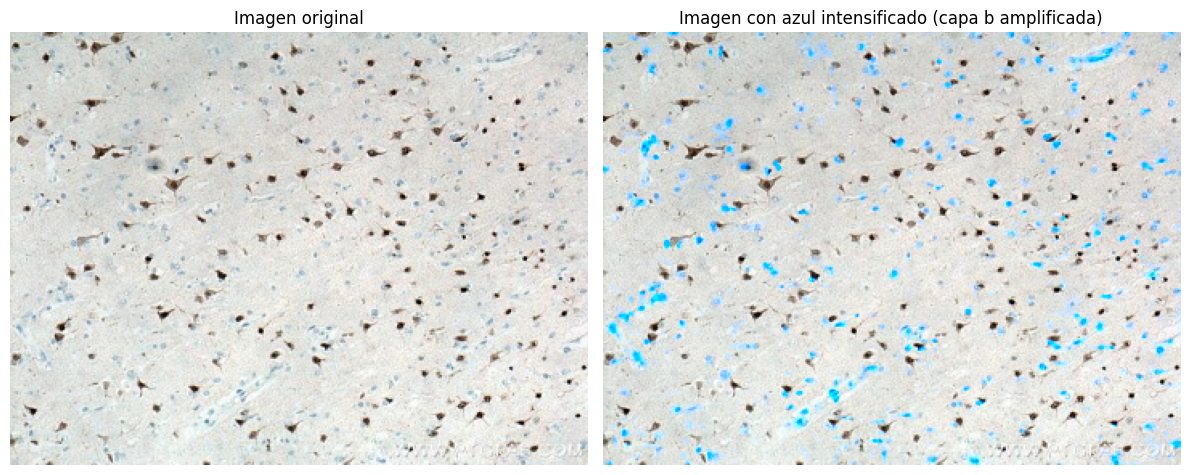

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2lab, lab2rgb

# Normalizar la imagen si no está en el rango [0, 1]
processing_image = img1.copy()
processing_image = processing_image.astype(np.float32) / 255.0  # Convertir a [0, 1] si es uint8

# Convertir la imagen de RGB a LAB
lab = rgb2lab(processing_image)

# Extraer las capas L, a, y b
L, a, b = lab[..., 0], lab[..., 1], lab[..., 2]

# Amplificar los valores negativos de la capa b (intensificar azul)
amplification_factor = 15 # Factor de amplificación
b_amplified = np.where(b < 0, b * amplification_factor, b)  # Solo amplifica valores negativos
b_amplified = np.clip(b_amplified, -110, 110)  # Mantener dentro del rango válido de b (-110 a +110)

# Reconstruir la imagen LAB con la capa b amplificada
lab_amplified = np.stack([L, a, b_amplified], axis=-1)

# Convertir de nuevo a RGB
img1_amplified = lab2rgb(lab_amplified)

# Mostrar resultados
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(processing_image)
plt.title("Imagen original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img1_amplified)
plt.title("Imagen con azul intensificado (capa b amplificada)")
plt.axis('off')

plt.tight_layout()
plt.show()

Como se observa, han sido únicamente las regiones negativas en el espacio *b LAB las que se han aumentado.

A continuación, probamos la segmentación por clústers en diferentes gamas de color, para ver cuál no ofrece mejor resultado.


--- RGB ---
Centroides:
[[0.862 0.872 0.864]
 [0.454 0.426 0.398]
 [0.273 0.776 0.979]]
Asignación: Células=clúster 2, Patógenos=clúster 0, Fondo=clúster 1

--- LAB ---
Centroides:
[[ 88.44   -0.941   1.813]
 [ 43.515   2.108   5.429]
 [ 82.144  -8.718 -23.941]]
Asignación: Células=clúster 2, Patógenos=clúster 1, Fondo=clúster 0

--- HSV ---
Centroides:
[[0.158 0.036 0.862]
 [0.531 0.722 0.935]
 [0.494 0.089 0.904]]
Asignación: Células=clúster 1, Patógenos=clúster 1, Fondo=clúster 0


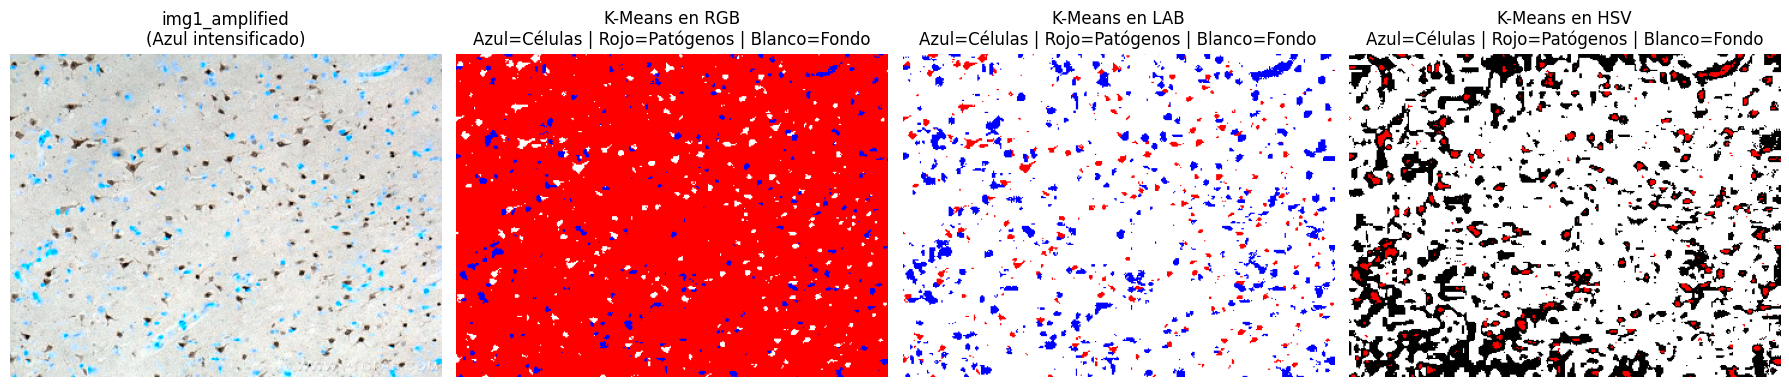

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from skimage.color import rgb2lab, rgb2hsv

# 1. IMAGEN: img1_amplified
img = img1_amplified.copy()
if img.max() > 1.0:
    img = img / 255.0

h, w, _ = img.shape

# 2. FUNCIÓN: K-Means en espacio 3D
def segment_kmeans_3d(img_space, space_name):
    pixels = img_space.reshape(-1, 3)
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pixels)
    segmented = labels.reshape(h, w)
    centers = kmeans.cluster_centers_

    # Asignar clústeres según canal relevante
    if space_name == "RGB":
        blue_idx = np.argmax(centers[:, 2])   # Mayor B → azul
        red_idx = np.argmax(centers[:, 0])    # Mayor R → rojo
    elif space_name == "LAB":
        blue_idx = np.argmin(centers[:, 2])   # b* más negativo → azul
        red_idx = np.argmax(centers[:, 1])    # a* positivo → rojo
    elif space_name == "HSV":
        blue_idx = np.argmax(centers[:, 1])   # Mayor saturación en azul
        red_idx = np.argmax(centers[:, 0])    # Mayor H en rojo

    # Fondo = restante
    idxs = [0, 1, 2]
    idxs.remove(blue_idx)
    if red_idx != blue_idx:
        idxs.remove(red_idx)
    bg_idx = idxs[0]

    # Imagen coloreada
    seg = np.zeros((h, w, 3))
    seg[segmented == blue_idx] = [0, 0, 1]      # Células
    seg[segmented == red_idx] = [1, 0, 0]       # Patógenos
    seg[segmented == bg_idx] = [1, 1, 1]        # Fondo

    return seg, centers, (blue_idx, red_idx, bg_idx)

# 3. APLICAR EN LOS 3 ESPACIOS
spaces = {
    "RGB": img.copy(),
    "LAB": rgb2lab(img),
    "HSV": rgb2hsv(img)
}

results = {}
for name, space_img in spaces.items():
    seg, centers, assignment = segment_kmeans_3d(space_img, name)
    results[name] = (seg, centers, assignment)

# 4. VISUALIZACIÓN
plt.figure(figsize=(18, 6))

# Imagen original
plt.subplot(1, 4, 1)
plt.imshow(img)
plt.title("img1_amplified\n(Azul intensificado)")
plt.axis('off')

# Segmentaciones
for i, (name, (seg, centers, (b_idx, r_idx, bg_idx))) in enumerate(results.items(), 2):
    plt.subplot(1, 4, i)
    plt.imshow(seg)
    plt.title(f"K-Means en {name}\nAzul=Células | Rojo=Patógenos | Blanco=Fondo")
    plt.axis('off')

    # Estadísticas
    print(f"\n--- {name} ---")
    print(f"Centroides:\n{np.round(centers, 3)}")
    print(f"Asignación: Células=clúster {b_idx}, Patógenos=clúster {r_idx}, Fondo=clúster {bg_idx}")

plt.tight_layout()
plt.show()

Es evidente que el mejor resultado nos lo aporta la segmentación por clústers en RGB que, ahora sí, después del aumento de tonalidad de las células, diferencia estas del fondo. Realizamos esta segmentación y seleccionamos el color marrón de clúster para los patógenos y azul claro para las células. El fondo se queda blanco.

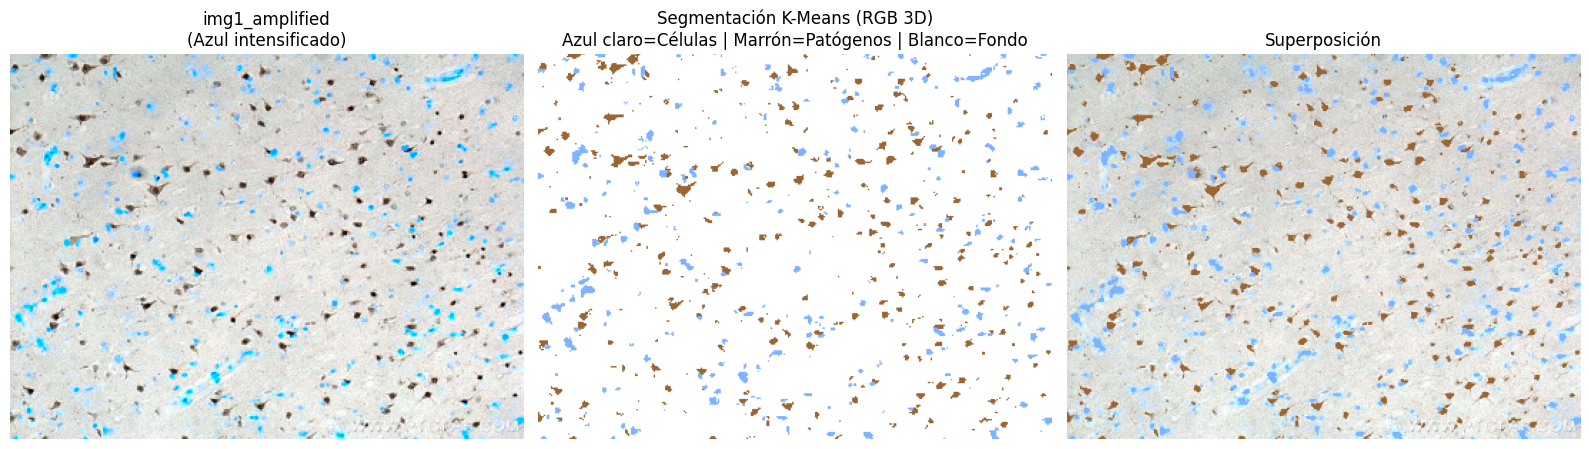

Segmentación K-Means en RGB 3D:
  • Células (azul claro):   2,623 píxeles
  • Patógenos (marrón):     3,165 píxeles
  • Fondo (blanco):         91,412 píxeles
  • Centroides RGB:
[[0.862 0.872 0.864]
 [0.454 0.426 0.398]
 [0.273 0.776 0.979]]
  • Relación R/B: [0.997 1.14  0.279]


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. IMAGEN: img1_amplified (RGB)
img = img1_amplified.copy()
if img.max() > 1.0:
    img = img / 255.0  # Normalizar a [0, 1]

h, w, _ = img.shape

# 2. K-MEANS EN RGB 3D
pixels = img.reshape(-1, 3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(pixels)
segmented = labels.reshape(h, w)

# 3. ASIGNAR CLÚSTERES SEGÚN RGB
centers = kmeans.cluster_centers_  # [R, G, B]

# Células: mayor valor B (azul intensificado)
cell_idx = np.argmax(centers[:, 2])

# Patógenos: mayor R y menor B → relación R/B alta
rb_ratio = centers[:, 0] / (centers[:, 2] + 1e-6)
pathogen_idx = np.argmax(rb_ratio)

# Fondo: el restante
idxs = [0, 1, 2]
idxs.remove(cell_idx)
if pathogen_idx != cell_idx:
    idxs.remove(pathogen_idx)
bg_idx = idxs[0]

# 4. COLORES PERSONALIZADOS
seg_rgb = np.zeros_like(img)

# Células → azul claro (RGB: 0.5, 0.7, 1.0)
seg_rgb[segmented == cell_idx] = [0.5, 0.7, 1.0]

# Patógenos → marrón (RGB: 0.6, 0.4, 0.2)
seg_rgb[segmented == pathogen_idx] = [0.6, 0.4, 0.2]

# Fondo → blanco
seg_rgb[segmented == bg_idx] = [1.0, 1.0, 1.0]

# 5. VISUALIZACIÓN
plt.figure(figsize=(16, 6))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("img1_amplified\n(Azul intensificado)")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(seg_rgb)
plt.title("Segmentación K-Means (RGB 3D)\nAzul claro=Células | Marrón=Patógenos | Blanco=Fondo")
plt.axis('off')

plt.subplot(1, 3, 3)
overlay = img.copy()
overlay[segmented == cell_idx]     = [0.5, 0.7, 1.0]
overlay[segmented == pathogen_idx] = [0.6, 0.4, 0.2]
plt.imshow(overlay)
plt.title("Superposición")
plt.axis('off')

plt.tight_layout()
plt.show()

# =============================================
# 6. ESTADÍSTICAS
# =============================================
print("Segmentación K-Means en RGB 3D:")
print(f"  • Células (azul claro):   {np.sum(segmented == cell_idx):,} píxeles")
print(f"  • Patógenos (marrón):     {np.sum(segmented == pathogen_idx):,} píxeles")
print(f"  • Fondo (blanco):         {np.sum(segmented == bg_idx):,} píxeles")
print(f"  • Centroides RGB:\n{np.round(centers, 3)}")
print(f"  • Relación R/B: {np.round(rb_ratio, 3)}")

Al superponer la imagen segmentada (en color) sobre la imagen original, se observa que ninguna región queda sin cubrir, lo que confirma que la identificación de las células teñidas y los patógenos ha sido satisfactoria.

A continuación, se realiza el conteo de elementos. Dado que en la imagen original aparecen estructuras de tamaño muy reducido (especialmente en el caso de los patógenos), se optó por contabilizar como célula o patógeno cualquier agrupación de píxeles, incluso aquellas compuestas por un solo píxel, sin establecer un umbral mínimo de tamaño.

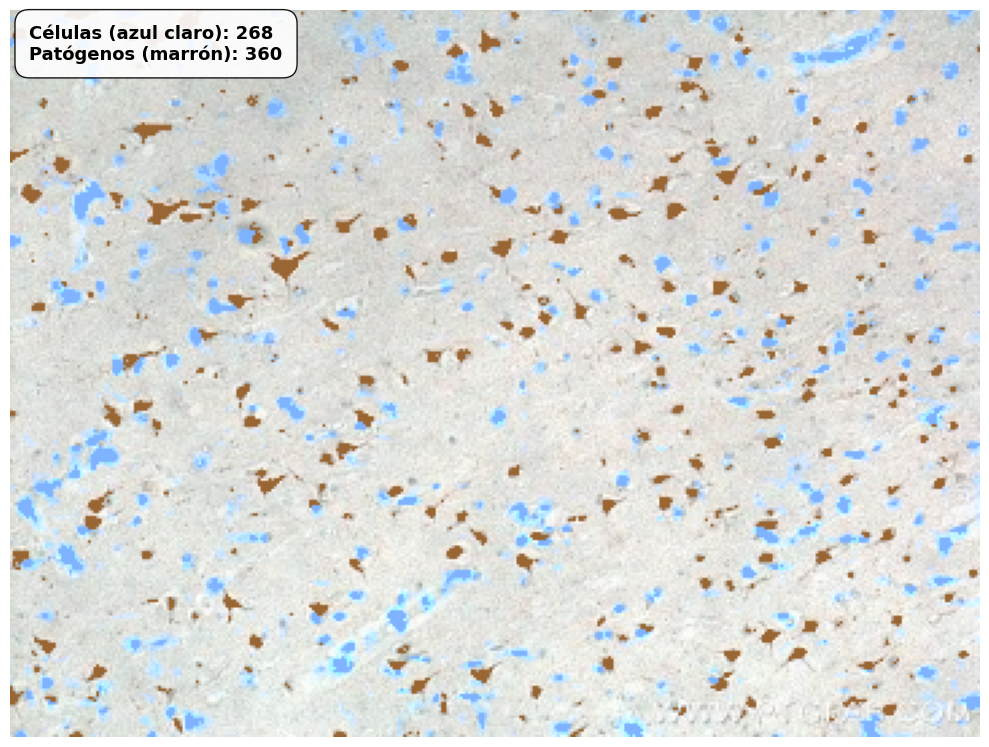

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from skimage.measure import label, regionprops

# 1. Carga y normalización
img = img1_amplified.copy()
if img.max() > 1.0:
    img = img / 255.0

h, w, _ = img.shape

# 2. K-Means en RGB (3 clústeres)
pixels = img.reshape(-1, 3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(pixels)
segmented = labels.reshape(h, w)

# 3. Identificación automática de clústeres
centers = kmeans.cluster_centers_
cell_idx     = np.argmax(centers[:, 2])                     # mayor B → células
rb_ratio     = centers[:, 0] / (centers[:, 2] + 1e-6)
pathogen_idx = np.argmax(rb_ratio)                         # mayor R/B → patógenos
bg_idx       = [i for i in range(3) if i not in (cell_idx, pathogen_idx)][0]

# 4. Conteo de objetos individuales
cells_mask      = segmented == cell_idx
pathogens_mask  = segmented == pathogen_idx

labeled_cells     = label(cells_mask)
labeled_pathogens = label(pathogens_mask)

num_cells     = len(regionprops(labeled_cells))
num_pathogens = len(regionprops(labeled_pathogens))

# 5. Superposición: imagen original + colores segmentados
overlay = img.copy()
overlay[segmented == cell_idx]     = [0.5, 0.7, 1.0]   # azul claro
overlay[segmented == pathogen_idx] = [0.6, 0.4, 0.2]   # marrón


fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(overlay)
ax.axis('off')

# Leyenda en la esquina superior-izquierda
legend = f"Células (azul claro): {num_cells}\nPatógenos (marrón): {num_pathogens}"
ax.text(0.02, 0.98, legend,
        transform=ax.transAxes,
        fontsize=13, fontweight='bold',
        verticalalignment='top',
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.8', alpha=0.9))

plt.tight_layout()
plt.show()

Se concluye que en esta imagen se encontraron 268 células teñidas y 360 patógenos. Sin embargo, algunos de los problemas que hemos encontrado son los siguientes:

La imagen tiene zonas con brillo y saturación variables, lo que cambia el color aparente de las células. El resultado es que ciertas áreas del fondo parecen más claras o más azules, generando falsos positivos o negativos.

Algunas áreas muestran un número de objetos fusionados o fragmentados.
Cuando dos manchas están muy próximas, se detectan como una sola, mietras que en otras, una célula se divide en dos regiones.

El algoritmo no separa bien los tonos marrones claros y los beige del fondo.
Parte del tejido se clasifica como marrón, lo que infla el conteo de patógenos. Esto pasa porque los colores son muy parecidos y las sombras afectan los umbrales.

Usar un algoritmo de watershed o distancia euclidiana podría separarlos correctamente antes del conteo.

Podríamos descartar ruido o falsos positivos filtrando las regiones detectadas:
por ejemplo, eliminar objetos demasiado pequeños o grandes para ser células o patógenos reales. Aunque en verdad no sabemos si, en la imagen original, esos pequeños elementos que se detectan son patógenos o células o simple ruido.